<a href="https://colab.research.google.com/github/sangaviyk/calculatordemo/blob/main/Task_1_ANN_%E2%80%93_Synthetic_Data_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

Generate a synthetic classification dataset using make_classification.


In [7]:
X,y = make_classification(
    n_samples=2000,
    n_features=10,
    n_classes=3,
    n_informative=8,
    n_redundant=2,
    n_clusters_per_class=1,
    random_state=42
)

Explore the generated dataset.

In [9]:
print("Shape of X",X.shape)
print("Shape of Y",y.shape)
print("Number of samples",X.shape[0])
print("Number of features",X.shape[1])
print("Number of classes",len(np.unique(y)))
print("Class distribution",np.bincount(y))

Shape of X (1000, 5)
Shape of Y (1000,)
Number of samples 1000
Number of features 5
Number of classes 3
Class distribution [333 336 331]


Visualize selected features to understand the class distribution.


Text(0.5, 1.0, 'Feature 0 vs Feature 1')

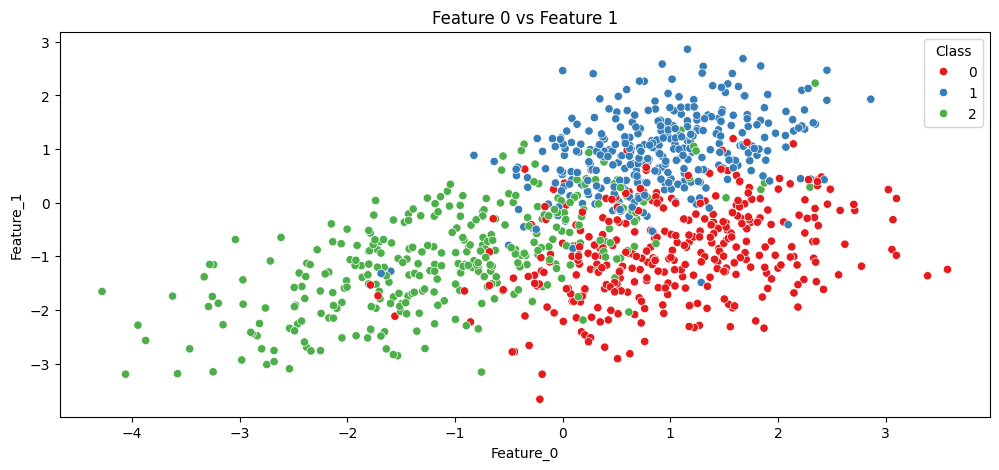

In [12]:
df = pd.DataFrame(X,columns=[f"Feature_{i}" for i in range (X.shape[1])])
df["Class"]=y

plt.figure(figsize=[12,5])
sns.scatterplot(x="Feature_0",y="Feature_1",hue="Class",data=df,palette="Set1")
plt.title("Feature 0 vs Feature 1")

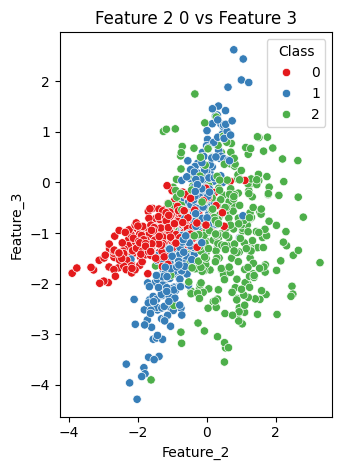

In [15]:
plt.subplot(1,2,2)
sns.scatterplot(x="Feature_2",y="Feature_3",hue="Class",data=df,palette="Set1")
plt.title("Feature 2 0 vs Feature 3")
plt.tight_layout()
plt.show()

Split the dataset into training and testing sets.

In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

Normalize the input features.

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Build an ANN using Dense layers.
Use ReLU activation for the hidden layers.
Use Softmax activation for the output layer.


In [20]:
model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(3,activation='softmax')
])

Compile and train the ANN model.

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

history= model.fit(
    X_train,y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5781 - loss: 1.0127 - val_accuracy: 0.6625 - val_loss: 0.9242
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7156 - loss: 0.8239 - val_accuracy: 0.7250 - val_loss: 0.7529
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8141 - loss: 0.6505 - val_accuracy: 0.8000 - val_loss: 0.6156
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8656 - loss: 0.5290 - val_accuracy: 0.8500 - val_loss: 0.5086
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8766 - loss: 0.4453 - val_accuracy: 0.8750 - val_loss: 0.4300
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8797 - loss: 0.3882 - val_accuracy: 0.8875 - val_loss: 0.3807
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8906 - loss: 0.3520 - val_accuracy: 0.8938 - val_loss: 0.3504
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8953 - loss: 0.3279 - val_accuracy: 0.9000 - val_loss

Evaluate the model using the test dataset.

In [24]:
test_loss,test_acc=model.evaluate(X_test,y_test,verbose=0)
print("\nTest Loss:{test_loss:4f}")
print("\nTest Accuracy:{test_acc:4f}")


Test Loss:{test_loss:4f}

Test Accuracy:{test_acc:4f}


Make predictions on test samples.

In [26]:
y_pred_probs=model.predict(X_test)
y_pred = np.argmax(y_pred_probs,axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


Compare actual vs predicted class labels.

In [28]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
print("\nActual vs Predicted(first 15):")
print(comparison.head(15))


Actual vs Predicted(first 15):
    Actual  Predicted
0        0          0
1        2          2
2        1          1
3        1          1
4        2          2
5        1          2
6        2          2
7        0          0
8        0          0
9        0          0
10       0          0
11       2          2
12       0          0
13       2          2
14       0          2


Calculate the classification accuracy.

In [29]:
acc= accuracy_score(y_test,y_pred)
print("\nClassificaton Accuracy:{acc:4f}")
print("\nClassificaton report:")
print(classification_report(y_test,y_pred))


Classificaton Accuracy:{acc:4f}

Classificaton report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        67
           1       0.93      0.93      0.93        67
           2       0.90      0.94      0.92        66

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



Display the confusion matrix.

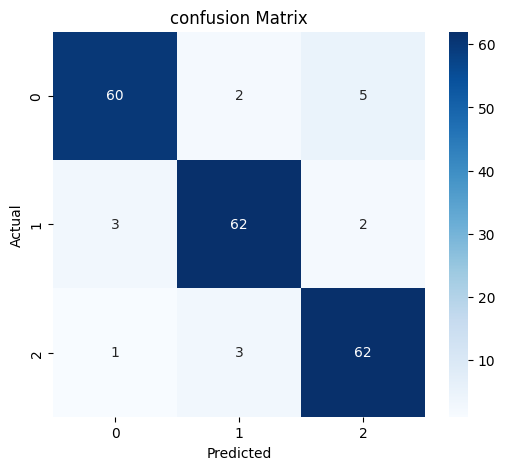

In [30]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=np.unique(y),yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix")
plt.show()